Loaded 12575 train, 1567 validation, and 1586 test samples.


config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,F1 Weighted,Precision Weighted,Recall Weighted,F1 Class 0,F1 Class 1,F1 Class 2
1,0.770079,0.687380,0.724952,0.699141,0.701392,0.701154,0.725333,0.730630,0.724952,0.534626,0.766323,0.796474
2,0.713820,0.671222,0.716656,0.701993,0.709810,0.710090,0.724844,0.747110,0.716656,0.556480,0.746429,0.803069
3,0.401224,0.702442,0.742821,0.726370,0.729735,0.732523,0.749831,0.764871,0.742821,0.578818,0.785160,0.815133
4,0.270880,0.818065,0.761966,0.738077,0.737904,0.739158,0.762381,0.763829,0.761966,0.585774,0.802980,0.825476
5,0.165839,0.976996,0.758775,0.731171,0.734280,0.729576,0.757235,0.757279,0.758775,0.568513,0.805556,0.819444


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

Evaluating on test set...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Test Results: {'accuracy': 0.7389659520807061, 'f1_macro': 0.7039009388786837, 'precision_macro': 0.7076303423960609, 'recall_macro': 0.7025821900585562, 'f1_weighted': 0.7344141391044515, 'precision_weighted': 0.7317852648106024, 'recall_weighted': 0.7389659520807061, 'f1_class_0': np.float64(0.5119047619047619), 'f1_class_1': np.float64(0.8011869436201781), 'f1_class_2': np.float64(0.7986111111111112)}


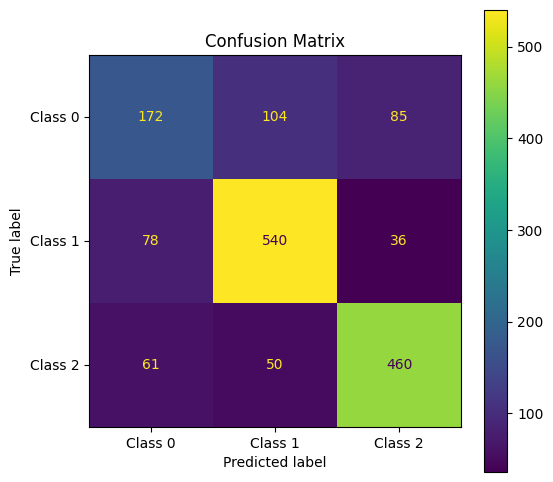

Cleaning up temporary files to free disk space...
Saving final model weights...
Model saved to feature_ensemble_model.pt
Model saved to feature_ensemble_model.pkl
Success! Model saved in both formats.


In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModel, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset
import os
import shutil
import transformers
from packaging import version
import pickle

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Configuration
BANGLABERT_NAME = "csebuetnlp/banglabert"
XLM_ROBERTA_NAME = "xlm-roberta-base"
MAX_LEN = 256 # Restored for better accuracy
BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 2e-5

class MultiModelDataset(Dataset):
    def __init__(self, texts, labels, tokenizer1, tokenizer2, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer1 = tokenizer1
        self.tokenizer2 = tokenizer2
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        # encoding1 = self.tokenizer1.encode_plus(
        #     text,
        #     add_special_tokens=True,
        #     max_length=self.max_len,
        #     padding='max_length',
        #     truncation=True,
        #     return_attention_mask=True,
        #     return_tensors='pt',
        # )

        # encoding2 = self.tokenizer2.encode_plus(
        #     text,
        #     add_special_tokens=True,
        #     max_length=self.max_len,
        #     padding='max_length',
        #     truncation=True,
        #     return_attention_mask=True,
        #     return_tensors='pt',
        # )

        encoding1 = self.tokenizer1(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        encoding2 = self.tokenizer2(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids1': encoding1['input_ids'].flatten(),
            'attention_mask1': encoding1['attention_mask'].flatten(),
            'input_ids2': encoding2['input_ids'].flatten(),
            'attention_mask2': encoding2['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

class FeatureEnsembleModel(nn.Module):
    def __init__(self, model1_name, model2_name, num_labels, class_weights=None):
        super(FeatureEnsembleModel, self).__init__()
        self.model1 = AutoModel.from_pretrained(model1_name)
        self.model2 = AutoModel.from_pretrained(model2_name)
        
        hidden_size1 = self.model1.config.hidden_size
        hidden_size2 = self.model2.config.hidden_size
        
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(hidden_size1 + hidden_size2, num_labels)
        self.num_labels = num_labels
        self.class_weights = class_weights

    def forward(self, input_ids1, attention_mask1, input_ids2, attention_mask2, labels=None):
        outputs1 = self.model1(input_ids=input_ids1, attention_mask=attention_mask1)
        features1 = outputs1.last_hidden_state[:, 0, :] 
        
        outputs2 = self.model2(input_ids=input_ids2, attention_mask=attention_mask2)
        features2 = outputs2.last_hidden_state[:, 0, :]
        
        combined_features = torch.cat((features1, features2), dim=1)
        combined_features = self.dropout(combined_features)
        
        logits = self.classifier(combined_features)
        
        loss = None
        if labels is not None:
            if self.class_weights is not None:
                loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
            else:
                loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))
            
        return (loss, logits) if loss is not None else logits

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average='macro')
    precision_macro = precision_score(labels, predictions, average='macro', zero_division=0)
    recall_macro = recall_score(labels, predictions, average='macro', zero_division=0)
    f1_weighted = f1_score(labels, predictions, average='weighted')
    precision_weighted = precision_score(labels, predictions, average='weighted', zero_division=0)
    recall_weighted = recall_score(labels, predictions, average='weighted', zero_division=0)
    
    # Per-class F1 scores
    f1_per_class = f1_score(labels, predictions, average=None, zero_division=0)
    
    metrics = {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_weighted': f1_weighted,
        'precision_weighted': precision_weighted,
        'recall_weighted': recall_weighted
    }
    
    # Add per-class F1 scores
    for i, f1_val in enumerate(f1_per_class):
        metrics[f'f1_class_{i}'] = f1_val
    
    return metrics

def main():
    # --- DATA PATHS ---
    train_path = '/kaggle/input/datasets/cryptexcode/sentnob-sentiment-analysis-in-noisy-bangla-texts/SentNoB Dataset/Train.csv'
    val_path = '/kaggle/input/datasets/cryptexcode/sentnob-sentiment-analysis-in-noisy-bangla-texts/SentNoB Dataset/Val.csv' 
    test_path = '/kaggle/input/datasets/cryptexcode/sentnob-sentiment-analysis-in-noisy-bangla-texts/SentNoB Dataset/Test.csv'
    
    # Load data
    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)
    
    print(f"Loaded {len(train_df)} train, {len(val_df)} validation, and {len(test_df)} test samples.")

    num_labels = 3 
    
    # Compute class weights to handle imbalance
    weights = compute_class_weight('balanced', classes=np.unique(train_df['Label']), y=train_df['Label'])
    class_weights = torch.tensor(weights, dtype=torch.float)

    tokenizer1 = AutoTokenizer.from_pretrained(BANGLABERT_NAME)
    tokenizer2 = AutoTokenizer.from_pretrained(XLM_ROBERTA_NAME)

    train_dataset = MultiModelDataset(train_df.Data.to_numpy(), train_df.Label.to_numpy(), tokenizer1, tokenizer2, MAX_LEN)
    val_dataset = MultiModelDataset(val_df.Data.to_numpy(), val_df.Label.to_numpy(), tokenizer1, tokenizer2, MAX_LEN)
    test_dataset = MultiModelDataset(test_df.Data.to_numpy(), test_df.Label.to_numpy(), tokenizer1, tokenizer2, MAX_LEN)

    model = FeatureEnsembleModel(BANGLABERT_NAME, XLM_ROBERTA_NAME, num_labels, class_weights=class_weights)

    # Handle version compatibility
    eval_strat_key = "eval_strategy" if version.parse(transformers.__version__) >= version.parse("4.41.0") else "evaluation_strategy"

    training_args = TrainingArguments(
        output_dir='./ensemble_results',
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        warmup_steps=500,
        weight_decay=0.01,
        logging_dir='./logs',
        logging_steps=10,
        **{eval_strat_key: "epoch"},
        save_strategy="no",
        report_to="none"
    )

    class EnsembleTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.get("labels")
            outputs = model(
                input_ids1=inputs.get("input_ids1"),
                attention_mask1=inputs.get("attention_mask1"),
                input_ids2=inputs.get("input_ids2"),
                attention_mask2=inputs.get("attention_mask2"),
                labels=labels
            )
            loss = outputs[0] if isinstance(outputs, tuple) else outputs
            return (loss, outputs) if return_outputs else loss

    trainer = EnsembleTrainer(model=model, args=training_args, train_dataset=train_dataset, eval_dataset=val_dataset, compute_metrics=compute_metrics)

    print("Starting training...")
    trainer.train()

    # print("Evaluating on test set...")
    # test_results = trainer.evaluate(test_dataset)
    # print(f"Test Results: {test_results}")

    print("Evaluating on test set...")

# Get predictions
    predictions_output = trainer.predict(test_dataset)

# Predicted labels
    y_pred = np.argmax(predictions_output.predictions, axis=1)

# True labels
    y_true = test_df.Label.to_numpy()

# Compute evaluation metrics
    test_results = compute_metrics((predictions_output.predictions, y_true))

    print(f"Test Results: {test_results}")

# Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
    disp = ConfusionMatrixDisplay(
         confusion_matrix=cm,
         display_labels=["Class 0", "Class 1", "Class 2"]
   )

    fig, ax = plt.subplots(figsize=(6,6))
    disp.plot(ax=ax)

    plt.title("Confusion Matrix")
    plt.show()

    # --- DISK CLEANUP BEFORE SAVE ---
    print("Cleaning up temporary files to free disk space...")
    if os.path.exists('./ensemble_results'):
        shutil.rmtree('./ensemble_results')
    if os.path.exists('./logs'):
        shutil.rmtree('./logs')

    # Save ONLY the final model weights
    print("Saving final model weights...")
    model.to('cpu') # Move to CPU to avoid memory spikes
    
    # Save as .pt file
    torch.save(model.state_dict(), "feature_ensemble_model.pt")
    print("Model saved to feature_ensemble_model.pt")
    
    # Save as .pkl file
    with open("feature_ensemble_model.pkl", "wb") as f:
        pickle.dump(model.state_dict(), f)
    print("Model saved to feature_ensemble_model.pkl")
    
    print("Success! Model saved in both formats.")

if __name__ == "__main__":
    main()